# **OOD : Out of Distribution Detection**

**train_set** : Only digits 1-9 training set

**id_test_set** : In distribution (1-9) test set


**zero_loader** : DataLoader of 0's

**fashion_loader** : DataLoader of FashionMNIST

**noise_set** : Noise (Gaussian)

In [ ]:
# Starter Code Block
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, Dataset, ConcatDataset
from torchvision import datasets, transforms
import random
import numpy as np

device = "mps"
random.seed(0)
torch.manual_seed(0)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
mnist_test  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
fashion_test = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

id_labels = set(range(1, 10))          # in-distribution: digits 1-9
label_map = {orig: i for i, orig in enumerate(sorted(id_labels))}  # 1-9 -> 0-8

def filter_indices(dataset, labels_to_keep):
    return [i for i, (_, y) in enumerate(dataset) if y in labels_to_keep]

class RemappedSubset(Dataset):
    """MNIST digits 1-9, relabeled to 0-8."""
    def __init__(self, dataset, indices, label_map):
        self.dataset, self.indices, self.label_map = dataset, indices, label_map
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        x, y = self.dataset[self.indices[idx]]
        return x, self.label_map[y]

# Training set: ONLY digits 1-9
train_idx = filter_indices(mnist_train, id_labels)
train_set = RemappedSubset(mnist_train, train_idx, label_map)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)

# ID test set: digits 1-9 only, for measuring clean classification accuracy
id_test_idx = filter_indices(mnist_test, id_labels)
id_test_set = RemappedSubset(mnist_test, id_test_idx, label_map)
id_test_loader = DataLoader(id_test_set, batch_size=256)

# OOD test sources — never touched during training
zero_idx = filter_indices(mnist_test, {0})
zero_loader = DataLoader(Subset(mnist_test, zero_idx), batch_size=256)     # digit 0
fashion_loader = DataLoader(fashion_test, batch_size=256)                  # FashionMNIST

from torch.utils.data import TensorDataset

# 1. Generate the noise images
noise_images = torch.randn(2000, 1, 28, 28)
# 2. Create dummy labels (label 9) for the 2000 images
noise_labels = torch.full((2000,), 9, dtype=torch.long)
# 3. Combine them into a proper Dataset
noise_dataset = TensorDataset(noise_images, noise_labels)
# 4. Create the loader
noise_loader = DataLoader(noise_dataset, batch_size=256)

# ---------------------------
# Model
# ---------------------------
class SmallCNN(nn.Module):
    def __init__(self, num_classes=9):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64 * 7 * 7, 128)
        self.fc2   = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.25)

    def forward(self,x,return_features=False):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.flatten(1)
        feat = F.relu(self.fc1(x))
        out = self.fc2(self.dropout(feat))
        if return_features:
            return out,feat  
        return out

model = SmallCNN(num_classes=9).to(device)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)
criterion = nn.CrossEntropyLoss()

# ---------------------------
# Train
# ---------------------------
def train_epoch(model,loader,optim=optimizer,criteria=criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optim.zero_grad()
        logits = model(x)
        loss = criteria(logits, y)
        loss.backward()
        optim.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate_accuracy(model,loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return correct / total

# ---------------------------
#   model                 -> trained 9-way classifier, forward(x, return_features=True) gives logits + penultimate features
#   id_test_loader        -> ID test data (digits 1-9, labels 0-8)
#   zero_loader           -> OOD: digit 0
#   fashion_loader        -> OOD: FashionMNIST
#   noise_loader          -> OOD: random noise
#
# ---------------------------

# Plain training of SmallCNN on pure 1-9 data with 8 label classifier
epochs = 7
for epoch in range(epochs):
    loss, acc = train_epoch(model, train_loader, optimizer, criterion)
    id_acc = evaluate_accuracy(model, id_test_loader)
    print(f"Epoch {epoch+1}: loss={loss:.4f}, train_acc={acc:.4f}, id_test_acc={id_acc:.4f}")

Epoch 1: loss=0.2083, train_acc=0.9344, id_test_acc=0.9839
Epoch 2: loss=0.0604, train_acc=0.9812, id_test_acc=0.9884
Epoch 3: loss=0.0462, train_acc=0.9855, id_test_acc=0.9894
Epoch 4: loss=0.0350, train_acc=0.9889, id_test_acc=0.9907
Epoch 5: loss=0.0278, train_acc=0.9913, id_test_acc=0.9907
Epoch 6: loss=0.0229, train_acc=0.9925, id_test_acc=0.9908
Epoch 7: loss=0.0214, train_acc=0.9923, id_test_acc=0.9936


Below are my experimentations and attempts at trying to solve OOD problem

________________________________________________________________________________________________
# **Idea 1** :
Insert random noise images into the training set and train the model to learn to classify these as class 10

In [3]:
class NoiseDataset(Dataset):
    def __init__(self,n,label):
        self.n = n
        self.label = label
    
    def __len__(self):
        return self.n
    
    def __getitem__(self,i):
        distribution = np.random.choice(["Gaussian","Uniform"])
        
        if distribution == "Gaussian":
            X = torch.randn(1,28,28)*0.5
        
        else:
            X = torch.rand(1,28,28)*2 - 1
    
        return (X,self.label)

label = 9
noise_train = NoiseDataset(n = len(train_set),label = label)
mix_train = ConcatDataset([train_set,noise_train])
mix_loader = DataLoader(mix_train,batch_size=128,shuffle=True)

In [4]:
class SmallCNN10(nn.Module):
    # We force num_classes to be 10
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1,out_channels=32,kernel_size=3,padding=1)
        self.conv2 = nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1)
        self.pool  = nn.MaxPool2d(2,2)
        self.fc1   = nn.Linear(64*7*7,128)
        self.fc2   = nn.Linear(128,10) 
        self.dropout = nn.Dropout(0.2)
    
    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        x = self.fc2(self.dropout(x))
        return x

In [5]:
import matplotlib.pyplot as plt

def OOD_accuracy(model,loader,reject_label):
    model.eval()
    ood,total = 0,0
    
    for batch,(X,y) in enumerate(loader):
        X = X.to(device)
        preds = model(X).argmax(1)
        ood += (preds==reject_label).type(torch.float).sum().item()
        total += len(X)

    return ood/total

Epoch 1: loss=0.0985 , train_acc = 0.9687
id_test_acc = 0.9820
zero_test_acc = 0.0000
fashion_acc = 0.2177
noise_acc = 1.0000

Epoch 2: loss=0.0278 , train_acc = 0.9915
id_test_acc = 0.9870
zero_test_acc = 0.0000
fashion_acc = 0.1917
noise_acc = 1.0000

Epoch 3: loss=0.0196 , train_acc = 0.9938
id_test_acc = 0.9918
zero_test_acc = 0.0000
fashion_acc = 0.1534
noise_acc = 1.0000

Epoch 4: loss=0.0151 , train_acc = 0.9952
id_test_acc = 0.9916
zero_test_acc = 0.0000
fashion_acc = 0.1333
noise_acc = 1.0000

Epoch 5: loss=0.0127 , train_acc = 0.9958
id_test_acc = 0.9897
zero_test_acc = 0.0000
fashion_acc = 0.1317
noise_acc = 1.0000

Epoch 6: loss=0.0094 , train_acc = 0.9968
id_test_acc = 0.9917
zero_test_acc = 0.0000
fashion_acc = 0.1451
noise_acc = 1.0000

Epoch 7: loss=0.0086 , train_acc = 0.9971
id_test_acc = 0.9906
zero_test_acc = 0.0000
fashion_acc = 0.1277
noise_acc = 1.0000

Epoch 8: loss=0.0075 , train_acc = 0.9973
id_test_acc = 0.9900
zero_test_acc = 0.0000
fashion_acc = 0.1409
nois

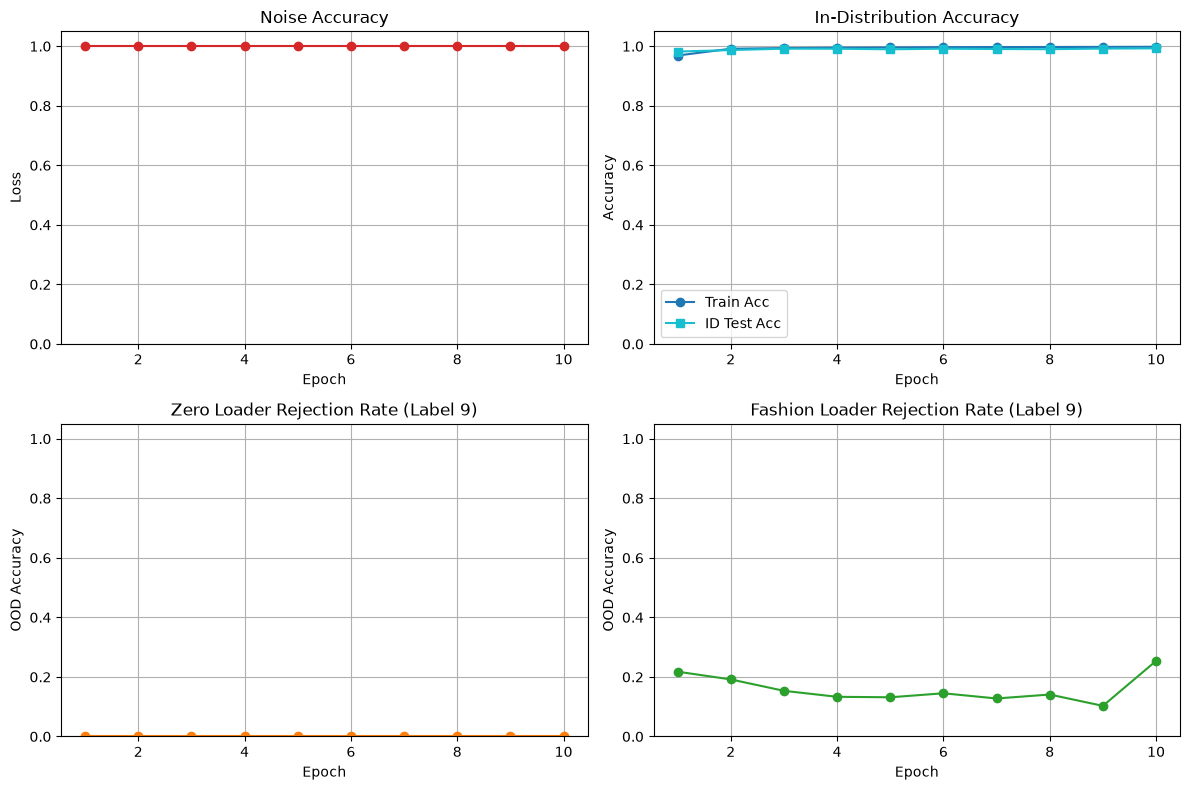

In [6]:
model1 = SmallCNN10().to(device)
optimizer1 = torch.optim.Adam(model1.parameters(),lr=1e-3)
criterion1 = nn.CrossEntropyLoss()

# Track metrics across epochs
history = {"loss": [],"train_acc": [],"id_acc": [],"zero_acc": [],"fashion_acc": [],"noise_acc":[]}

epochs = 10
for epoch in range(epochs):
    loss, acc = train_epoch(model1, mix_loader, optimizer1, criterion1)
    id_acc = evaluate_accuracy(model1, id_test_loader)
    zero_acc = OOD_accuracy(model1, zero_loader, 9)
    fashion_acc = OOD_accuracy(model1, fashion_loader, 9)
    noise_acc = OOD_accuracy(model1, noise_loader,9)

    history["loss"].append(loss)
    history["train_acc"].append(acc)
    history["id_acc"].append(id_acc)
    history["zero_acc"].append(zero_acc)
    history["fashion_acc"].append(fashion_acc)
    history["noise_acc"].append(noise_acc)

    print(
        f"Epoch {epoch+1}: loss={loss:.4f} , train_acc = {acc:.4f}\n"
        f"id_test_acc = {id_acc:.4f}\n"
        f"zero_test_acc = {zero_acc:.4f}\n"
        f"fashion_acc = {fashion_acc:.4f}\n"
        f"noise_acc = {noise_acc:.4f}\n"
    )

epoch_range = range(1,epochs + 1)
fig,axs = plt.subplots(2,2, figsize=(12, 8))

# 1. Noise Accuracy
axs[0, 0].plot(epoch_range, history["noise_acc"], marker="o", color="tab:red")
axs[0, 0].set_title("Noise Accuracy")
axs[0, 0].set_xlabel("Epoch")
axs[0, 0].set_ylabel("Loss")
axs[0, 0].set_ylim(0,1.05)
axs[0, 0].grid(True)

# 2. In-Distribution Accuracy (Train vs Test)
axs[0, 1].plot(
    epoch_range,
    history["train_acc"],
    marker="o",
    label="Train Acc",
    color="tab:blue",
)
axs[0, 1].plot(
    epoch_range,
    history["id_acc"],
    marker="s",
    label="ID Test Acc",
    color="tab:cyan",
)
axs[0, 1].set_title("In-Distribution Accuracy")
axs[0, 1].set_xlabel("Epoch")
axs[0, 1].set_ylabel("Accuracy")
axs[0, 1].set_ylim(0, 1.05)
axs[0, 1].legend()
axs[0, 1].grid(True)

# 3. Zero OOD Detection Rate (Class 0 as OOD)
axs[1, 0].plot(epoch_range, history["zero_acc"], marker="o", color="tab:orange")
axs[1, 0].set_title("Zero Loader Rejection Rate (Label 9)")
axs[1, 0].set_xlabel("Epoch")
axs[1, 0].set_ylabel("OOD Accuracy")
axs[1, 0].set_ylim(0, 1.05)
axs[1, 0].grid(True)

# 4. Fashion-MNIST OOD Detection Rate
axs[1, 1].plot(
    epoch_range, history["fashion_acc"], marker="o", color="tab:green"
)
axs[1, 1].set_title("Fashion Loader Rejection Rate (Label 9)")
axs[1, 1].set_xlabel("Epoch")
axs[1, 1].set_ylabel("OOD Accuracy")
axs[1, 1].set_ylim(0, 1.05)
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()


- The model obviously performs very well in In-Distribution dataset

- It also performs very well on Noise dataset since they are clearly very different from hand drawn 
digits

- It performs poorly on FashionMNIST dataset which has edge like features, not easy for model to distinguish from MNIST dataset

- It performs EXTREMELY POOR on 0 MNIST data : the reason most probably is that because handstrokes are quite difficult for model to distinguish into OOD and it misclassifies into one of the other handwritten digits

________________________________________________________________________________________________
# **Idea 2 :**
**CNN Code Distance thresholdoing**

Extract peultimate layer features from CNN model for every training image before classifier layers then find distance of test image's CNN code distance from nearest class mean from ID 
Distance > Threshold : Classify as OOD

In [7]:
@torch.no_grad()
def extract_features(model,loader):
    model.eval()
    feats,labels = [],[]
    
    for X,y in loader:
        X,y = X.to(device),y.to(device)
        
        _,f = model(X,return_features = True)
        feats.append(f)
        labels.append(y)    
    return torch.cat(feats),torch.cat(labels)

train_feats,train_labels = extract_features(model,train_loader)
class_means = torch.stack([train_feats[train_labels==c].mean(dim=0) for c in range(9)]).to(device)


def euclidean_dist(feats):
    dists = torch.cdist(feats,class_means)
    return dists.min(dim=1).values

In [8]:
@torch.no_grad
def get_dists(model,loader):
    model.eval()
    dists = []
    for batch,(X,y) in enumerate(loader):
        X = X.to(device)
        _,f = model(X,return_features=True)
        dists.append(euclidean_dist(f))
    return torch.cat(dists)

id_dists = get_dists(model,id_test_loader)
zero_dists = get_dists(model,zero_loader)
fashion_dists = get_dists(model,fashion_loader)
noise_dists = get_dists(model,noise_loader)

percentiles = torch.tensor([0.80,0.90,0.95,0.99]).to(device)
thresholds = torch.quantile(id_dists,percentiles).to(device)

print(f"{'ID Kept%':<10} | {'Threshold':<10} | {'Digit 0 OOD%':<14} | {'Fashion OOD%':<14} | {'Noise OOD%':<12}")
print("-" * 70)

# Evaluate each threshold
for p,thresh in zip(percentiles, thresholds):
    # Calculate percentage of OOD samples correctly flagged (True Negative Rate)
    d0_ood = (zero_dists > thresh).float().mean().item() * 100
    fashion_ood = (fashion_dists > thresh).float().mean().item() * 100
    noise_ood = (noise_dists > thresh).float().mean().item() * 100
    
    print(f"{p.item()*100:<9.1f}% | {thresh.item():<10.3f} | {d0_ood:<13.2f}% | {fashion_ood:<13.2f}% | {noise_ood:<11.2f}%")


ID Kept%   | Threshold  | Digit 0 OOD%   | Fashion OOD%   | Noise OOD%  
----------------------------------------------------------------------
80.0     % | 27.130     | 99.08        % | 81.78        % | 100.00     %
90.0     % | 30.002     | 95.71        % | 49.82        % | 81.40      %
95.0     % | 32.354     | 88.47        % | 14.48        % | 0.00       %
99.0     % | 37.038     | 42.14        % | 1.53         % | 0.00       %


OOD Dataset     | AUROC Score
------------------------------
Digit 0         | 0.9748
FashionMNIST    | 0.8708
Noise           | 0.9087


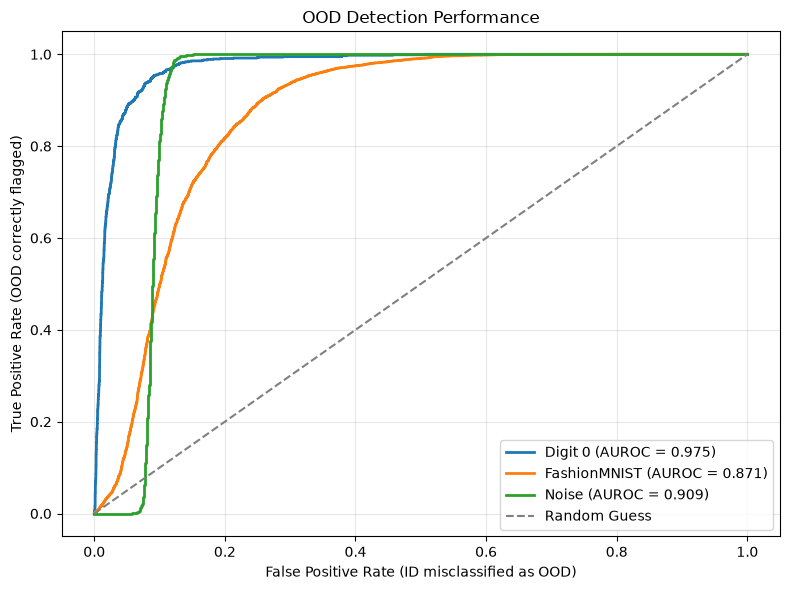

In [9]:
from sklearn.metrics import roc_curve,roc_auc_score

id_scores = id_dists.cpu().numpy()

ood_datasets = {
    "Digit 0": zero_dists.cpu().numpy(),
    "FashionMNIST": fashion_dists.cpu().numpy(),
    "Noise": noise_dists.cpu().numpy()
}

plt.figure(figsize=(8,6))

print(f"{'OOD Dataset':<15} | {'AUROC Score':<10}")
print("-" * 30)

for name,ood_scores in ood_datasets.items():
    y_true = [0] * len(id_scores) + [1] * len(ood_scores)
    
    y_scores = list(id_scores) + list(ood_scores)
    
    auroc = roc_auc_score(y_true,y_scores)
    print(f"{name:<15} | {auroc:.4f}")
    
    fpr,tpr,thresholds = roc_curve(y_true,y_scores)
    
    plt.plot(fpr,tpr,lw=2,label=f"{name} (AUROC = {auroc:.3f})")
    
    
plt.plot([0, 1],[0, 1],linestyle='--',color='gray',label='Random Guess')
plt.xlabel("False Positive Rate (ID misclassified as OOD)")
plt.ylabel("True Positive Rate (OOD correctly flagged)")
plt.title("OOD Detection Performance")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


- Peformance is very good on 0 which should have probably been hardest given it is also hand drawn and similar to trianing examples !

- Performance on Noise is good but should/could have been better since it is very different from the data trained upon : *Need to think about why this happened*

- Performance on FashionMNIST is worst most probably due to edge detection, edge collections being very similar blocks in CNN code extracted making it tough for OOD 


*Green curve shoots up suddenly to 1 : This means most noise samples lie in this threshold region*

Plausible explaination : CNN filters detect patterns/structures - It finds none in Noise and filters give nearly 0 responses - ReLU kills all negative ones : We only have very few non zero components left, we end up in noise images ending up as short arrows in similar directions

This messes up our Euclidian threshold

So one fix is to normalise all vectors to magnitude 1, then only their directions will matter
Noise has random directions and all those accumulated noise data will be spread out with normalisation : Hence the next attempt will be normalising all to magnitude 1 so that only direction matters and the clustered OODs spread out

# **Idea 2+ :**
**CNN Code distance thresholding after normalisation**

In [10]:
train_feats,train_labels = extract_features(model,train_loader)
train_feats_normalised = F.normalize(train_feats,p=2,dim=1)

class_means = torch.stack([train_feats_normalised[train_labels==c].mean(dim=0) for c in range(9)])
class_means = F.normalize(class_means,p=2,dim=1).to(device)

def euclidean_dist_normalised(feats):
    feats_normalised = F.normalize(feats,p=2,dim=1)
    dists = torch.cdist(feats_normalised,class_means)
    return dists.min(dim=1).values

@torch.no_grad
def get_dists_normalised(model,loader):
    model.eval()
    dists = []
    for batch,(X,y) in enumerate(loader):
        X = X.to(device)
        _,f = model(X,return_features=True)
        dists.append(euclidean_dist_normalised(f))
    return torch.cat(dists)

id_dists = get_dists_normalised(model,id_test_loader)
zero_dists = get_dists_normalised(model,zero_loader)
fashion_dists = get_dists_normalised(model,fashion_loader)
noise_dists = get_dists_normalised(model,noise_loader)

percentiles = torch.tensor([0.80,0.90,0.95,0.99]).to(device)
thresholds = torch.quantile(id_dists,percentiles).to(device)

print(f"{'ID Kept%':<10} | {'Threshold':<10} | {'Digit 0 OOD%':<14} | {'Fashion OOD%':<14} | {'Noise OOD%':<12}")
print("-" * 70)

# Evaluate each threshold
for p, thresh in zip(percentiles, thresholds):
    # Calculate percentage of OOD samples correctly flagged (True Negative Rate)
    d0_ood = (zero_dists > thresh).float().mean().item() * 100
    fashion_ood = (fashion_dists > thresh).float().mean().item() * 100
    noise_ood = (noise_dists > thresh).float().mean().item() * 100
    
    print(f"{p.item()*100:<9.1f}% | {thresh.item():<10.3f} | {d0_ood:<13.2f}% | {fashion_ood:<13.2f}% | {noise_ood:<11.2f}%")



ID Kept%   | Threshold  | Digit 0 OOD%   | Fashion OOD%   | Noise OOD%  
----------------------------------------------------------------------
80.0     % | 0.581      | 99.59        % | 98.53        % | 99.45      %
90.0     % | 0.667      | 97.45        % | 92.72        % | 96.20      %
95.0     % | 0.743      | 92.14        % | 79.64        % | 86.15      %
99.0     % | 0.872      | 69.69        % | 31.86        % | 48.95      %


OOD Dataset     | AUROC Score
------------------------------
Digit 0         | 0.9845
FashionMNIST    | 0.9661
Noise           | 0.9768


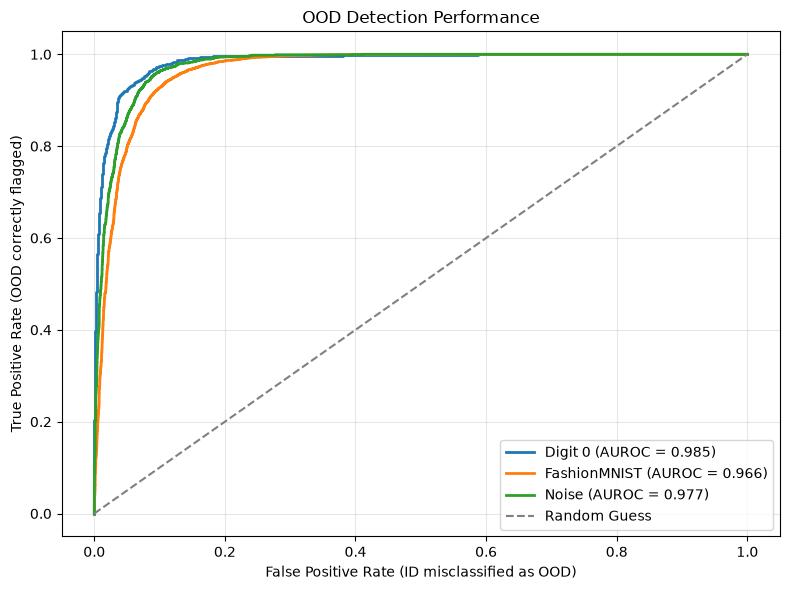

In [11]:
from sklearn.metrics import roc_curve,roc_auc_score

id_scores = id_dists.cpu().numpy()

ood_datasets = {
    "Digit 0": zero_dists.cpu().numpy(),
    "FashionMNIST": fashion_dists.cpu().numpy(),
    "Noise": noise_dists.cpu().numpy()
}

plt.figure(figsize=(8,6))

print(f"{'OOD Dataset':<15} | {'AUROC Score':<10}")
print("-" * 30)

for name,ood_scores in ood_datasets.items():
    y_true = [0] * len(id_scores) + [1] * len(ood_scores)
    
    y_scores = list(id_scores) + list(ood_scores)
    
    auroc = roc_auc_score(y_true,y_scores)
    print(f"{name:<15} | {auroc:.4f}")
    
    fpr,tpr,thresholds = roc_curve(y_true,y_scores)
    
    plt.plot(fpr,tpr,lw=2,label=f"{name} (AUROC = {auroc:.3f})")
    
    
plt.plot([0, 1],[0, 1],linestyle='--',color='gray',label='Random Guess')
plt.xlabel("False Positive Rate (ID misclassified as OOD)")
plt.ylabel("True Positive Rate (OOD correctly flagged)")
plt.title("OOD Detection Performance")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
